In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from traincae import DEFAULT_PARAMS, SlidingWindowDataset
from findAnomalies import load_model, reconstruct_signal_from_windows
from plotReconstructionTraining import plot_signal
from random import randint
from tqdm import tqdm

In [29]:
def plot_signal(original_df,reconstructed_df,column,unit,mode):

    # Picking a column randomly
    #ind = randint(0,len(original_df.columns)-1)
    #column = original_df.columns[ind]
    #column='charge'
    plt.figure(figsize=(10, 6))
    plt.plot(reconstructed_df[column][100:1000], label=f'Reconstructed Signal of {column}', color='b', alpha=0.6)
    plt.plot(original_df[column][100:1000], label="Original", color='r', linestyle='--', alpha=0.6)
    plt.xlabel('Time index')
    plt.ylabel('Value')
    plt.ylim(-0.05,1.05)
    plt.title(f'Reconstructed Signal of {column}')
    plt.grid()
    plt.legend()

    plt.savefig(f"../images/reconstruction_training_{unit}_{mode}.pdf")


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def getTrainingReconstructDf(unit,mode):
    print(f"\n=== Loading Training {unit}-{mode} ===")
    training_df = pd.read_parquet(f'data/training_{unit}_{mode}.parquet')

    # Create dataset for evaluation
    train_dataset = SlidingWindowDataset(
        training_df,
        window=DEFAULT_PARAMS['window_size'],
        device=device
    )

    # Create dataloader
    train_loader = DataLoader(
        train_dataset,
        batch_size=DEFAULT_PARAMS['batch_size'],
        shuffle=False  # Important: keep order for anomaly detection
    )
    print("\n=== Loading Model ===")
    _, _, model = load_model(unit = unit, mode = mode)

    print(f"\n=== Reconstructin {unit}-{mode} ===")
    reconstructed_test_df = reconstruct_signal_from_windows(train_loader, training_df, model, device)

    return training_df, reconstructed_test_df


In [3]:
training_VG4_pump_df, reconstruct_VG4_pump = getTrainingReconstructDf("VG4","pump")
training_VG4_turbine_df, reconstruct_VG4_turbine = getTrainingReconstructDf("VG4","turbine")
training_VG5_pump_df, reconstruct_VG5_pump = getTrainingReconstructDf("VG5","pump")
training_VG5_turbine_df, reconstruct_VG5_turbine = getTrainingReconstructDf("VG5","turbine")
training_VG6_pump_df, reconstruct_VG6_pump = getTrainingReconstructDf("VG6","pump")
training_VG6_turbine_df, reconstruct_VG6_turbine = getTrainingReconstructDf("VG6","turbine")


=== Loading Training VG4-pump ===


/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that 


=== Loading Model ===

=== Reconstructin VG4-pump ===


Reconstructing signals: 100%|██████████| 348/348 [00:13<00:00, 25.43it/s]
/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for


=== Loading Training VG4-turbine ===

=== Loading Model ===

=== Reconstructin VG4-turbine ===


...

Reconstructing signals: 100%|██████████| 504/504 [00:23<00:00, 21.32it/s]



=== Loading Training VG6-turbine ===

=== Loading Model ===


/home/matthieu/Documents/ML predictive maintenance/.venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/matthieu/Documents/ML predictive maintenance/Project/MLPM/SERVERFILES_CAE/findAnomalies.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that 


=== Reconstructin VG6-turbine ===


Reconstructing signals: 100%|██████████| 1309/1309 [01:02<00:00, 20.92it/s]


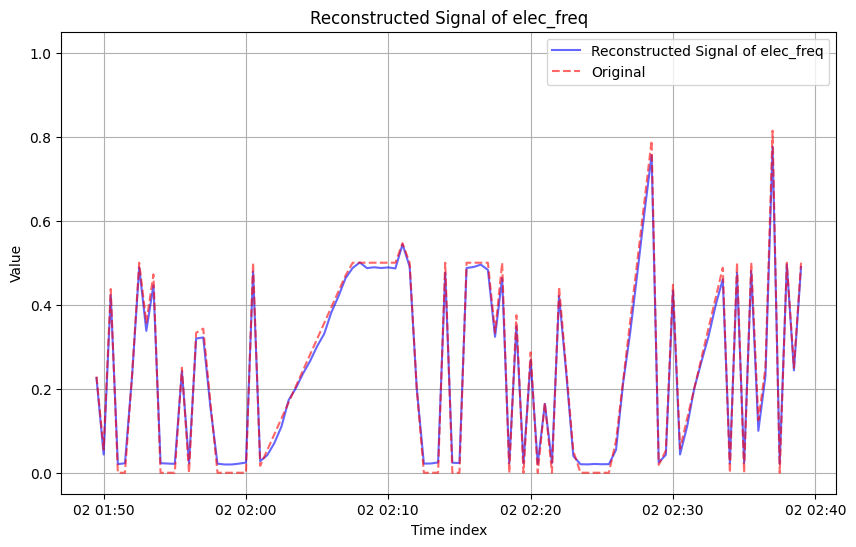

In [34]:
plot_signal(training_VG4_pump_df[100:300],reconstruct_VG4_pump[100:300],"elec_freq",'VG4',"pump",)

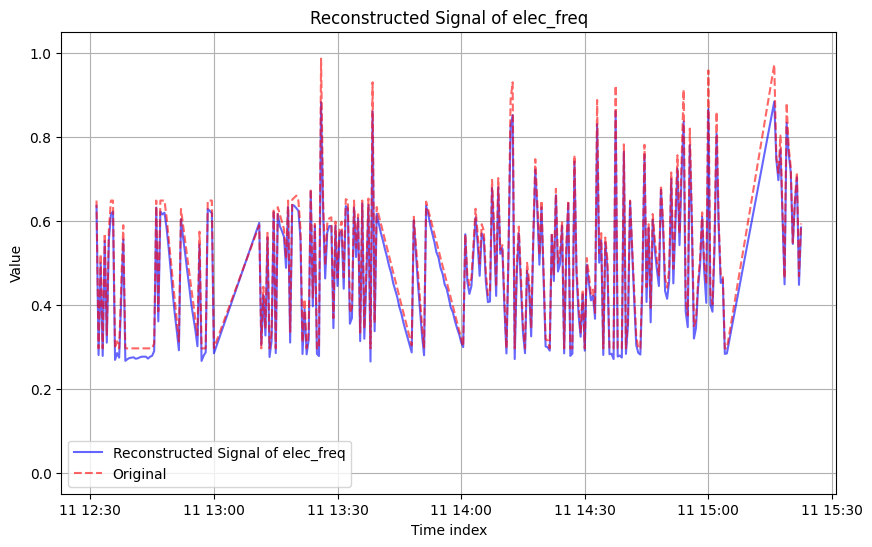

In [57]:
plot_signal(training_VG4_turbine_df[1500:1900],reconstruct_VG4_turbine[1500:1900],
            "elec_freq",'VG4',"turbine")

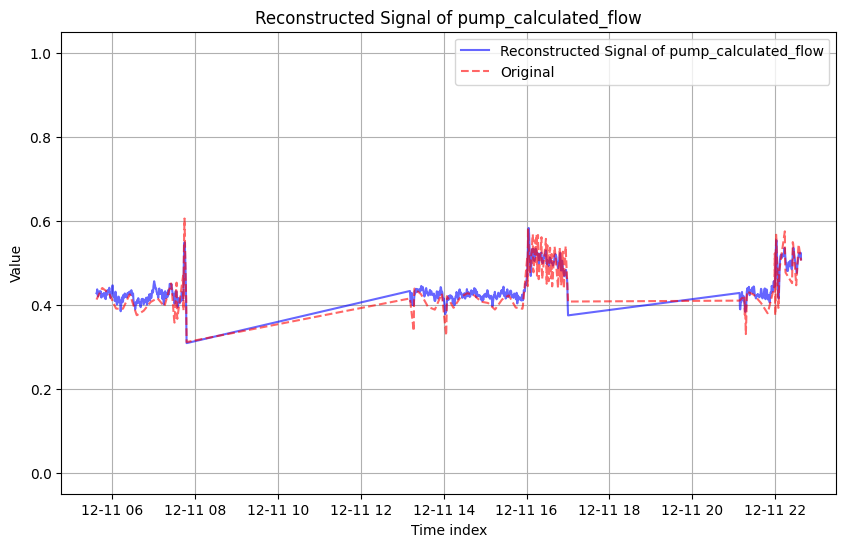

In [91]:
plot_signal(training_VG5_pump_df[123000:126000],reconstruct_VG5_pump[123000:126000],
            "pump_calculated_flow",'VG5',"pump")

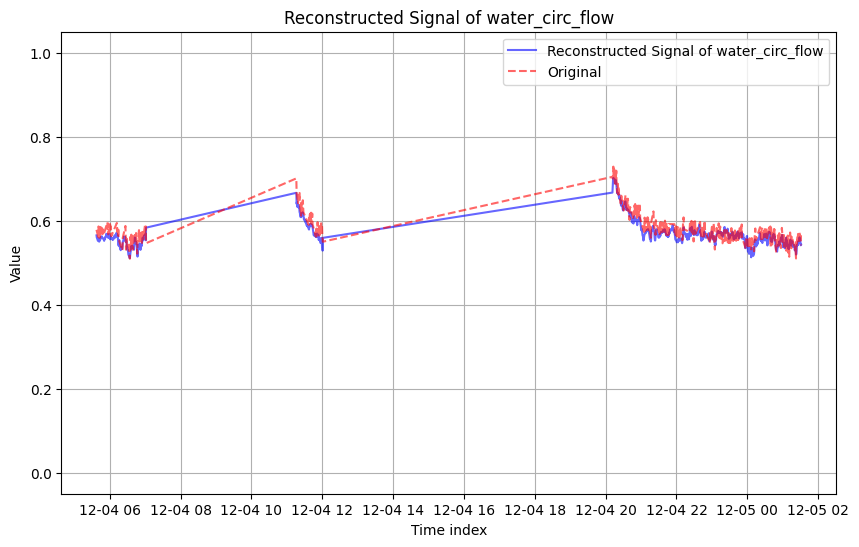

In [95]:
plot_signal(training_VG6_pump_df[110000:120000],reconstruct_VG6_pump[110000:120000],
            "water_circ_flow",'VG6',"pump")

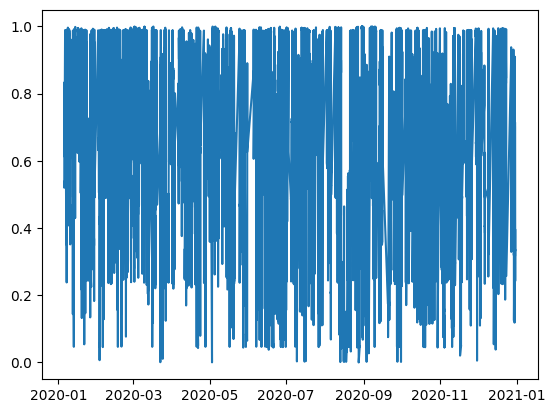

In [104]:
plt.plot(training_VG6_turbine_df["charge"])

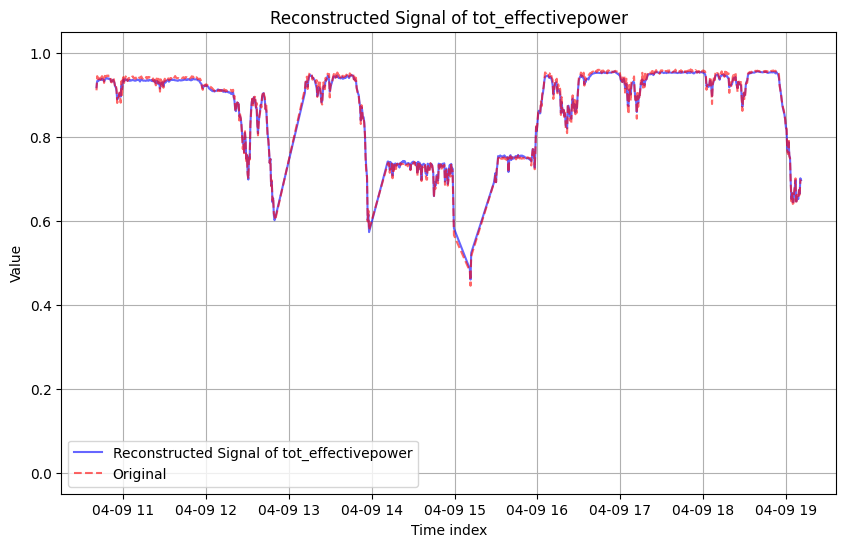

In [109]:
plot_signal(training_VG6_turbine_df[100000:109000],reconstruct_VG6_turbine[100000:109000],
            "tot_effectivepower",'VG6',"turbine")